In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
threads = 8

In [5]:
!jellyfish count -m 23 -s 8G -t {threads} -C -L 4 -o ../data/assemblies/ColCEN.jf ../data/assemblies/ColCEN.fasta
!jellyfish count -m 23 -s 8G -t {threads} -C -L 4 -o ../data/assemblies/ColPEK.jf ../data/assemblies/ColPEK.fasta
!jellyfish count -m 23 -s 8G -t {threads} -C -L 4 -o ../data/assemblies/ColXJTU.jf ../data/assemblies/ColXJTU.fasta

In [10]:
!jellyfish dump -c -t -L 4 ../data/assemblies/ColCEN.jf > ../data/assemblies/ColCEN.4x.tsv
!jellyfish dump -c -t -L 4 ../data/assemblies/ColPEK.jf > ../data/assemblies/ColPEK.4x.tsv
!jellyfish dump -c -t -L 4 ../data/assemblies/ColXJTU.jf > ../data/assemblies/ColXJTU.4x.tsv

In [11]:
dfs = {
    assembly: pd.read_csv(
        f"../data/assemblies/{assembly}.4x.tsv",
        sep="\t",
        header=None,
        names=["kmer", assembly],
        index_col="kmer",
    )
    for assembly in ['ColCEN', 'ColPEK', 'ColXJTU']
}

df = pd.concat(dfs.values(), axis=1)
df.shape

(958687, 3)

In [12]:
df.head()

,ColCEN,ColPEK,ColXJTU
kmer,,,
AAAAAAAAAAAAAAAAAAAAAAA,3558.0,3486.0,3509.0
ATCCAAAGCAAATTGAGAACCGA,4.0,4.0,4.0
AGTCAACTATACTTCTCAACTCA,11.0,11.0,11.0
CACATTTCGATTCTTTTATAAGA,6.0,6.0,6.0
AAGTATAGGTTCGATCACCCCAC,4.0,4.0,4.0


In [13]:
pd.Series(df.values.flatten()).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99],
)

count    2.791593e+06
mean     2.169563e+01
std      3.747201e+02
min      4.000000e+00
1%       4.000000e+00
5%       4.000000e+00
10%      4.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      1.100000e+01
90%      2.200000e+01
95%      4.200000e+01
99%      1.480000e+02
max      3.530700e+04
dtype: float64

In [30]:
df_hi = df.loc[df.max(axis=1) >= 10]
df_hi.shape

(271728, 3)

In [31]:
df_hi.head()

,ColCEN,ColPEK,ColXJTU
kmer,,,
AAAAAAAAAAAAAAAAAAAAAAA,3558.0,3486.0,3509.0
AGTCAACTATACTTCTCAACTCA,11.0,11.0,11.0
TAACAAGAACAGAAAGTAAACCA,12.0,12.0,12.0
CACTTGATCCTATCAGAACACCA,22.0,27.0,27.0
CCCCGAAAATGGATGGCGCTTAA,19.0,65.0,61.0


In [27]:
df_mutac = pd.read_feather("../data/joined-counts.20x-cov.na-filled.zstd-8.feather")
df_mutac.shape

(18822594, 179)

In [32]:
df_joined = df_hi.join(df_mutac, how="inner")
df_joined.shape

(270781, 182)

In [40]:
df_joined.sample(64)

,ColCEN,ColPEK,ColXJTU,SRR6862404,SRR6862406,SRR6862407,SRR6862408,SRR6862409,SRR6862410,SRR6862411,...,SRR6750179,SRR6750180,SRR6750181,SRR6750188,SRR6750190,SRR6750191,SRR6750192,SRR6750193,SRR6750194,SRR6750204
kmer,,,,,,,,,,,,,,,,,,,,,
ATTCATTTACCGTGGGTCCCACC,30.0,33.0,33.0,11.527572,12.979860,11.674491,12.427047,11.502913,12.396767,11.382548,...,13.824363,12.226820,12.539468,13.527574,12.554593,14.727226,13.729348,12.829106,12.891549,11.486652
AAAGACAAAGACTCATACGAACT,10.0,11.0,11.0,5.172195,5.987020,6.141419,4.836874,5.556124,4.734444,4.977160,...,5.691351,5.487852,5.384488,5.951217,4.649849,5.379808,6.269677,5.727280,5.791281,4.759267
CGCTTCTCAGCACTCTCTACAGA,25.0,25.0,25.0,9.769702,10.106091,11.587584,9.971403,10.027067,9.562330,10.690074,...,10.908423,11.459089,11.809368,11.032640,11.368882,10.692369,12.343981,9.988376,12.038724,9.232263
GAAAAGCAATATCAAAAATGATA,33.0,33.0,33.0,16.158884,18.152647,17.931786,17.747608,18.491476,18.408264,16.965624,...,18.654985,21.098373,18.489782,19.066782,17.529932,17.529209,19.679325,18.052385,17.135843,17.068951
GGAAAAATATTGATTTTATTAAA,11.0,11.0,11.0,4.496091,5.268578,5.446165,5.878663,5.990196,5.513135,6.102431,...,5.779181,6.653665,5.658275,5.676545,5.905309,5.312561,5.896693,5.956371,6.128444,5.832787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCGTGAGGAGCGGGGTATGCTC,24.0,24.0,24.0,7.775195,10.441363,8.864502,9.673749,9.245738,8.721343,8.829049,...,10.873292,12.454296,11.353055,10.162847,10.299417,10.513042,10.336974,9.576012,10.590903,9.339615
GTTTATCTATAGAATGGATCGAA,24.0,24.0,24.0,10.209169,11.447184,11.008205,11.124811,11.068841,10.745941,10.213998,...,11.593493,11.970910,12.156165,11.261533,10.834149,10.087141,11.189507,11.042195,11.364396,9.089128
ACAGGGCCACGAATCTCTGGAAT,22.0,22.0,22.0,9.262624,9.770818,9.820477,10.789951,10.504547,10.683645,9.781201,...,11.154346,11.658131,11.316550,11.971101,9.253201,10.647538,10.656674,10.171649,10.511571,8.767072


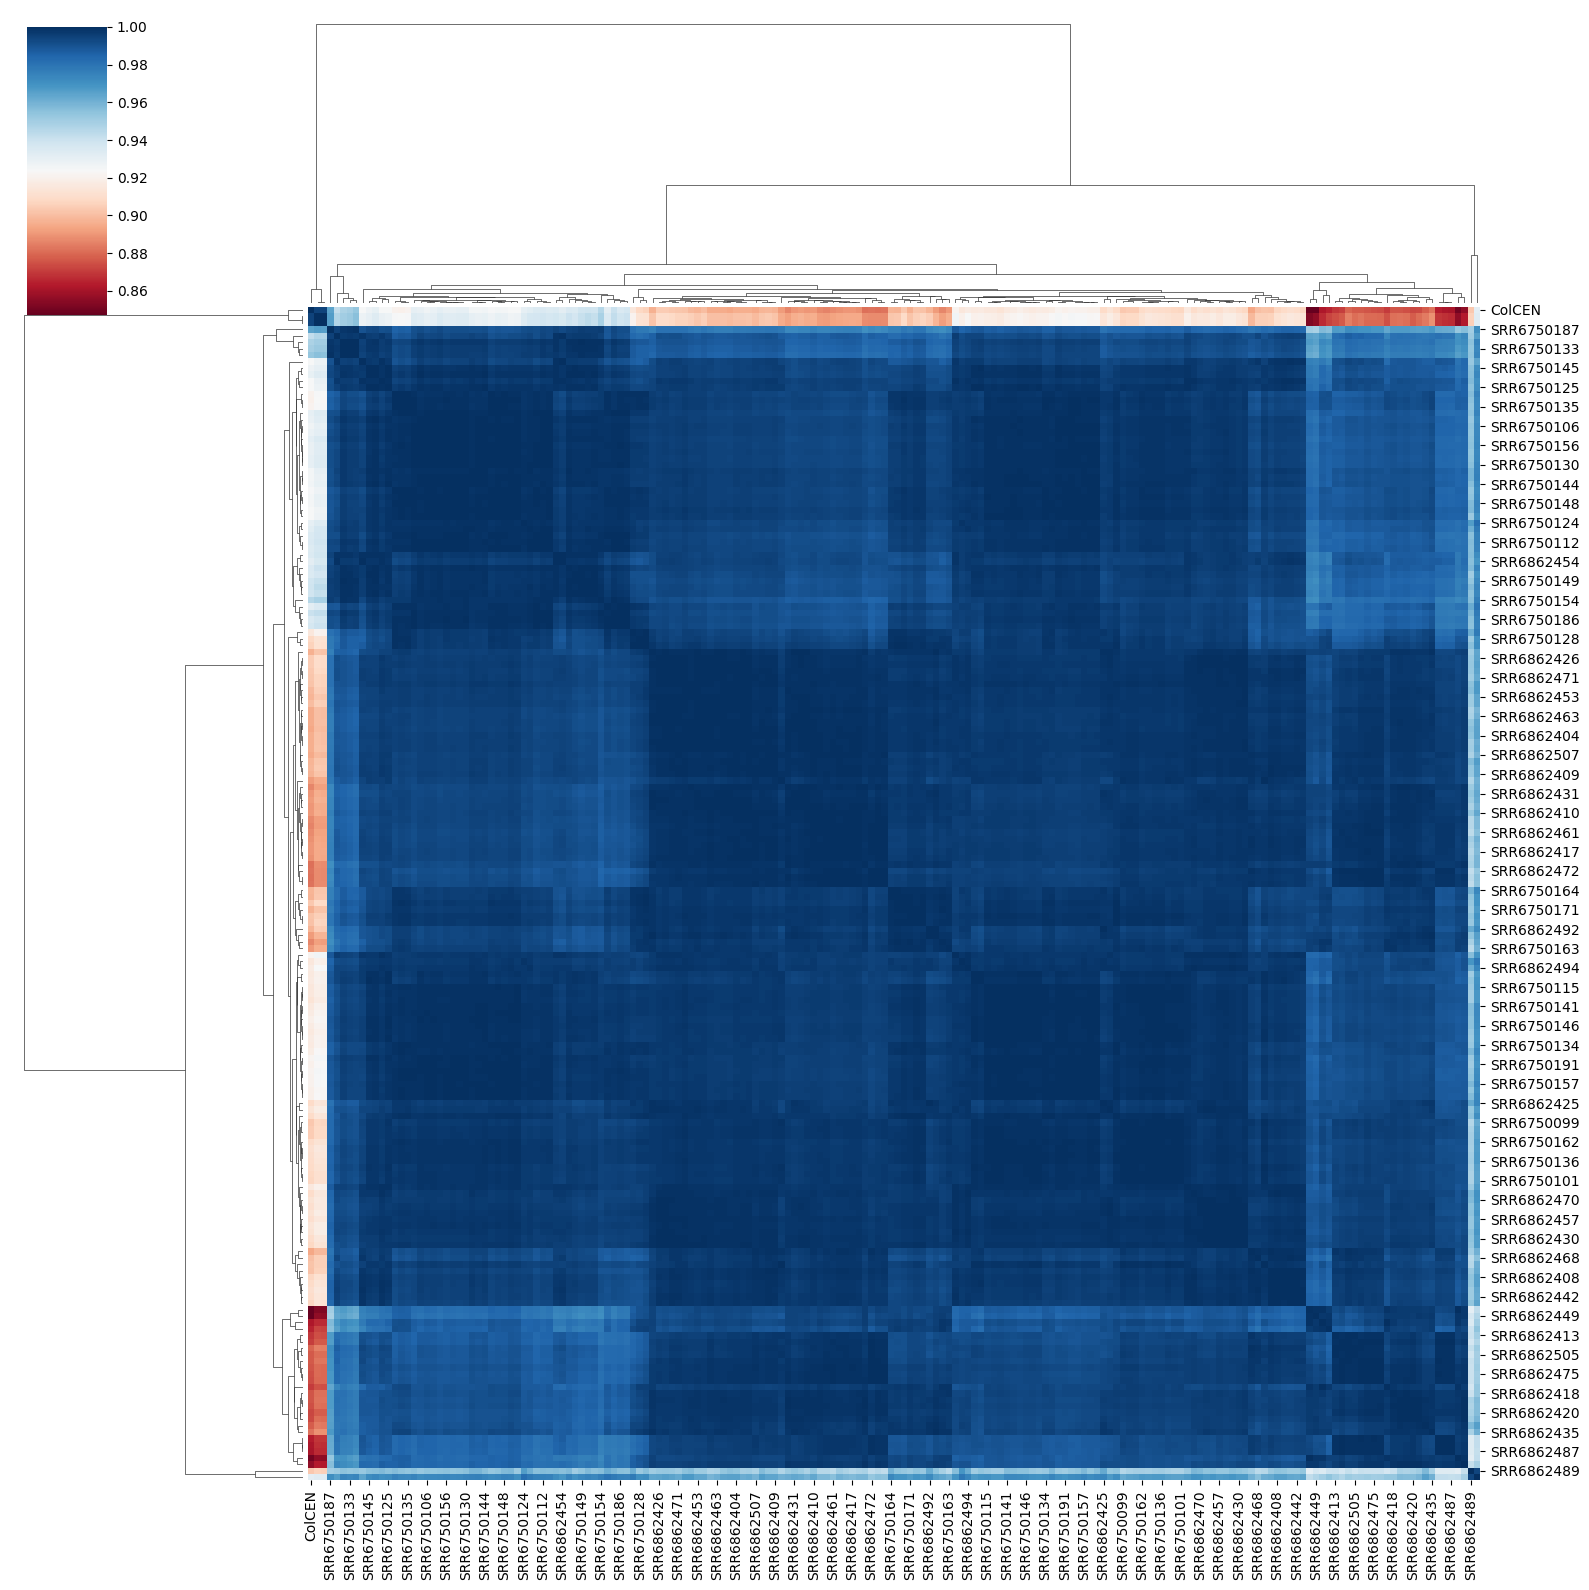

In [39]:
sns.clustermap(
    df_joined.corr(),
    cmap="RdBu",
    figsize=(16, 16),
)